In [1]:
import sys
from pathlib import Path
import time
import json

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import math

def find_project_root(marker="data/imagenet100"):
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find project root containing {marker}")

PROJECT_ROOT = find_project_root()
EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "embeddings"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results"
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [2]:
def load_embeddings(split):
    path = EMBEDDINGS_DIR / f"{split}_embeddings.pt"
    data = torch.load(path, weights_only=True)
    return data["features"], data["labels"]


train_features, train_labels = load_embeddings("train")
val_features, val_labels = load_embeddings("val")
heldout_features, heldout_labels = load_embeddings("heldout")

train_dataset = TensorDataset(train_features, train_labels)
val_dataset = TensorDataset(val_features, val_labels)
heldout_dataset = TensorDataset(heldout_features, heldout_labels)

BATCH_SIZE = 512

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
heldout_loader = DataLoader(heldout_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_features):,} | Val: {len(val_features):,} | Heldout: {len(heldout_features):,}")

Train: 117,000 | Val: 13,000 | Heldout: 5,000


In [3]:
class AsymmetricBilinearClassifier(nn.Module):
    """
    Prototype-based classifier with asymmetric bilinear similarity.
    
    Computes logit_i = x · M · Π_i, where:
        - Π_i is the learned prototype for class i
        - M = S + γA, with S symmetric and A skew-symmetric
        - S = (Q + Q^T) / 2, derived from learnable Q
        - A = (R - R^T) / 2, derived from learnable R
        - γ is a fixed hyperparameter controlling asymmetry strength
    
    At initialization (Q = I, R = 0), the model is equivalent to a randomly-
    initialized linear classifier: logit_i = x · I · Π_i = x · Π_i.
    
    Args:
        embed_dim: dimensionality of input features (2048 for Barlow Twins)
        n_classes: number of output classes (100)
        gamma: scalar controlling skew-symmetric contribution to M (default 1.0)
    """
    def __init__(self, embed_dim=2048, n_classes=100, gamma=1.0):
        super().__init__()
        self.embed_dim = embed_dim
        self.n_classes = n_classes
        self.gamma = gamma
        
        # Q is initialized to identity matrix
        # Then S = (Q + Q^T) / 2 = I (identity is its own transpose)
        self.Q = nn.Parameter(torch.eye(embed_dim))
        
        # R is initialized to zero
        # Then A = (R - R^T) / 2 = 0
        self.R = nn.Parameter(torch.zeros(embed_dim, embed_dim))
        
        # Prototypes initialized like nn.Linear weights:
        # Kaiming uniform with fan_in = embed_dim
        self.prototypes = nn.Parameter(torch.empty(n_classes, embed_dim))
        # Same init formula as nn.Linear with bias=False
        nn.init.kaiming_uniform_(self.prototypes, a=math.sqrt(5))
    
    def compute_M(self):
        """Compute the similarity matrix M = S + γA from Q and R."""
        S = (self.Q + self.Q.T) / 2
        A = (self.R - self.R.T) / 2
        M = S + self.gamma * A
        return M, S, A
    
    def forward(self, x):
        # x has shape [B, embed_dim]
        # M has shape [embed_dim, embed_dim]
        # prototypes has shape [n_classes, embed_dim]
        
        M, _, _ = self.compute_M()
        
        # logit_i = x · M · Π_i for all i
        # = (x @ M) @ Π_i^T for each i
        # = (x @ M) @ prototypes.T
        # 
        # Shape math:
        #   x @ M:                    [B, embed_dim]
        #   (x @ M) @ prototypes.T:   [B, n_classes]
        logits = (x @ M) @ self.prototypes.T
        return logits


# Instantiate and inspect
GAMMA = 1.0
model = AsymmetricBilinearClassifier(embed_dim=2048, n_classes=100, gamma=GAMMA).to(device)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: AsymmetricBilinearClassifier")
print(f"γ (gamma): {GAMMA}")
print(f"Total parameters: {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")
print(f"\nParameter breakdown:")
print(f"  Q: {model.Q.shape} = {model.Q.numel():,} params")
print(f"  R: {model.R.shape} = {model.R.numel():,} params")
print(f"  Π: {model.prototypes.shape} = {model.prototypes.numel():,} params")

Model: AsymmetricBilinearClassifier
γ (gamma): 1.0
Total parameters: 8,593,408
Trainable parameters: 8,593,408

Parameter breakdown:
  Q: torch.Size([2048, 2048]) = 4,194,304 params
  R: torch.Size([2048, 2048]) = 4,194,304 params
  Π: torch.Size([100, 2048]) = 204,800 params


In [4]:
# Verify the initialization invariants
with torch.no_grad():
    M, S, A = model.compute_M()
    
    print(f"M shape: {M.shape}")
    print(f"\n=== Symmetric part S ===")
    print(f"  S vs I: max abs diff = {(S - torch.eye(2048, device=device)).abs().max().item():.6e}")
    print(f"  Is S symmetric? max|S - S.T| = {(S - S.T).abs().max().item():.6e}")
    
    print(f"\n=== Skew-symmetric part A ===")
    print(f"  A vs 0: max abs value = {A.abs().max().item():.6e}")
    print(f"  Is A skew-symmetric? max|A + A.T| = {(A + A.T).abs().max().item():.6e}")
    
    print(f"\n=== M = S + γA ===")
    print(f"  M vs I: max abs diff = {(M - torch.eye(2048, device=device)).abs().max().item():.6e}")
    
    # Most important check: does forward pass through M produce same result as identity?
    features, labels = next(iter(train_loader))
    features = features.to(device)
    
    # Forward through the model (which uses M)
    logits_via_M = model(features)
    
    # Forward as if M were identity: just x @ prototypes.T
    logits_via_identity = features @ model.prototypes.T
    
    print(f"\n=== Forward pass check ===")
    print(f"  At init, model should produce same logits as 'x @ Π.T'")
    print(f"  Max abs diff: {(logits_via_M - logits_via_identity).abs().max().item():.6e}")

M shape: torch.Size([2048, 2048])

=== Symmetric part S ===
  S vs I: max abs diff = 0.000000e+00
  Is S symmetric? max|S - S.T| = 0.000000e+00

=== Skew-symmetric part A ===
  A vs 0: max abs value = 0.000000e+00
  Is A skew-symmetric? max|A + A.T| = 0.000000e+00

=== M = S + γA ===
  M vs I: max abs diff = 0.000000e+00

=== Forward pass check ===
  At init, model should produce same logits as 'x @ Π.T'
  Max abs diff: 0.000000e+00


In [5]:
features, labels = next(iter(train_loader))
features = features.to(device)
labels = labels.to(device)

logits = model(features)

print(f"Input shape:  {features.shape}")
print(f"Output shape: {logits.shape}")
print(f"Output dtype: {logits.dtype}")
print(f"Output stats: mean={logits.mean():.4f}, std={logits.std():.4f}")
print(f"Output range: [{logits.min():.4f}, {logits.max():.4f}]")
print(f"Random prediction accuracy: {(logits.argmax(dim=1) == labels).float().mean():.4f}")

Input shape:  torch.Size([512, 2048])
Output shape: torch.Size([512, 100])
Output dtype: torch.float32
Output stats: mean=-0.0068, std=0.0682
Output range: [-0.3293, 0.2852]
Random prediction accuracy: 0.0078


In [6]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)
        
        logits = model(features)
        loss = criterion(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * features.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += features.size(0)
    
    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)
        
        logits = model(features)
        loss = criterion(logits, labels)
        
        total_loss += loss.item() * features.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += features.size(0)
    
    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def measure_asymmetry(model):
    """Measure how much asymmetric structure has developed in M."""
    M, S, A = model.compute_M()
    return {
        "S_frob_norm": S.norm().item(),
        "A_frob_norm": A.norm().item(),
        "M_frob_norm": M.norm().item(),
        # Ratio of skew-symmetric to symmetric magnitude
        # 0 means M is fully symmetric, ∞ means fully skew-symmetric
        "asymmetry_ratio": (A.norm() / S.norm()).item(),
    }


def fit_asymmetric(model, train_loader, val_loader, optimizer, criterion, device, n_epochs):
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
        "S_frob_norm": [], "A_frob_norm": [], "asymmetry_ratio": [],
    }
    
    print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | "
          f"{'Val Loss':>9} | {'Val Acc':>8} | {'‖S‖':>6} | {'‖A‖':>6} | {'A/S':>5} | {'Time':>6}")
    print("-" * 100)
    
    for epoch in range(1, n_epochs + 1):
        start = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        asym = measure_asymmetry(model)
        elapsed = time.time() - start
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["S_frob_norm"].append(asym["S_frob_norm"])
        history["A_frob_norm"].append(asym["A_frob_norm"])
        history["asymmetry_ratio"].append(asym["asymmetry_ratio"])
        
        print(f"{epoch:>5} | {train_loss:>10.4f} | {train_acc:>8.2%} | "
              f"{val_loss:>9.4f} | {val_acc:>7.2%} | "
              f"{asym['S_frob_norm']:>6.2f} | {asym['A_frob_norm']:>6.3f} | "
              f"{asym['asymmetry_ratio']:>5.3f} | {elapsed:>5.1f}s")
    
    return history


# Hyperparameters (identical to Step 8 for fair comparison)
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
N_EPOCHS = 30
GAMMA = 1.0

# Fresh model
model = AsymmetricBilinearClassifier(embed_dim=2048, n_classes=100, gamma=GAMMA).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print(f"Training asymmetric bilinear classifier")
print(f"  γ = {GAMMA}, λ = 0 (no asymmetry hinge loss)")
print(f"  {N_EPOCHS} epochs, lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY}\n")

history = fit_asymmetric(model, train_loader, val_loader, optimizer, criterion, device, n_epochs=N_EPOCHS)

print(f"\nFinal asymmetry ratio: {history['asymmetry_ratio'][-1]:.4f}")
print(f"Best validation accuracy: {max(history['val_acc']):.4f} "
      f"(epoch {history['val_acc'].index(max(history['val_acc'])) + 1})")

Training asymmetric bilinear classifier
  γ = 1.0, λ = 0 (no asymmetry hinge loss)
  30 epochs, lr=0.001, weight_decay=0.0001

Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc |    ‖S‖ |    ‖A‖ |   A/S |   Time
----------------------------------------------------------------------------------------------------
    1 |     0.7039 |   81.65% |    0.5269 |  84.13% |  48.33 | 30.509 | 0.631 |   6.1s
    2 |     0.4360 |   86.77% |    0.5129 |  84.54% |  44.10 | 31.439 | 0.713 |   5.6s
    3 |     0.4020 |   87.70% |    0.5212 |  84.34% |  41.04 | 31.863 | 0.776 |   5.5s
    4 |     0.3877 |   87.99% |    0.4968 |  84.82% |  39.29 | 32.292 | 0.822 |   5.5s
    5 |     0.3746 |   88.38% |    0.5007 |  85.12% |  38.06 | 32.401 | 0.851 |   5.6s
    6 |     0.3680 |   88.51% |    0.5056 |  85.01% |  37.37 | 32.489 | 0.869 |   5.5s
    7 |     0.3603 |   88.71% |    0.4970 |  84.92% |  36.96 | 32.519 | 0.880 |   5.3s
    8 |     0.3548 |   88.81% |    0.5197 |  84.15% |  36.67 | 32.477 | 0.

In [7]:
checkpoint_path = CHECKPOINTS_DIR / "proposed_asymmetric_g1.0_l0.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "history": history,
    "hyperparameters": {
        "embed_dim": 2048,
        "n_classes": 100,
        "gamma": GAMMA,
        "lambda_asym": 0.0,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "n_epochs": N_EPOCHS,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
    },
    "final_metrics": {
        "train_loss": history["train_loss"][-1],
        "train_acc": history["train_acc"][-1],
        "val_loss": history["val_loss"][-1],
        "val_acc": history["val_acc"][-1],
        "best_val_acc": max(history["val_acc"]),
        "best_val_epoch": history["val_acc"].index(max(history["val_acc"])) + 1,
        "final_S_norm": history["S_frob_norm"][-1],
        "final_A_norm": history["A_frob_norm"][-1],
        "final_asymmetry_ratio": history["asymmetry_ratio"][-1],
    },
}, checkpoint_path)

print(f"Saved to {checkpoint_path}")

Saved to /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/checkpoints/proposed_asymmetric_g1.0_l0.pt


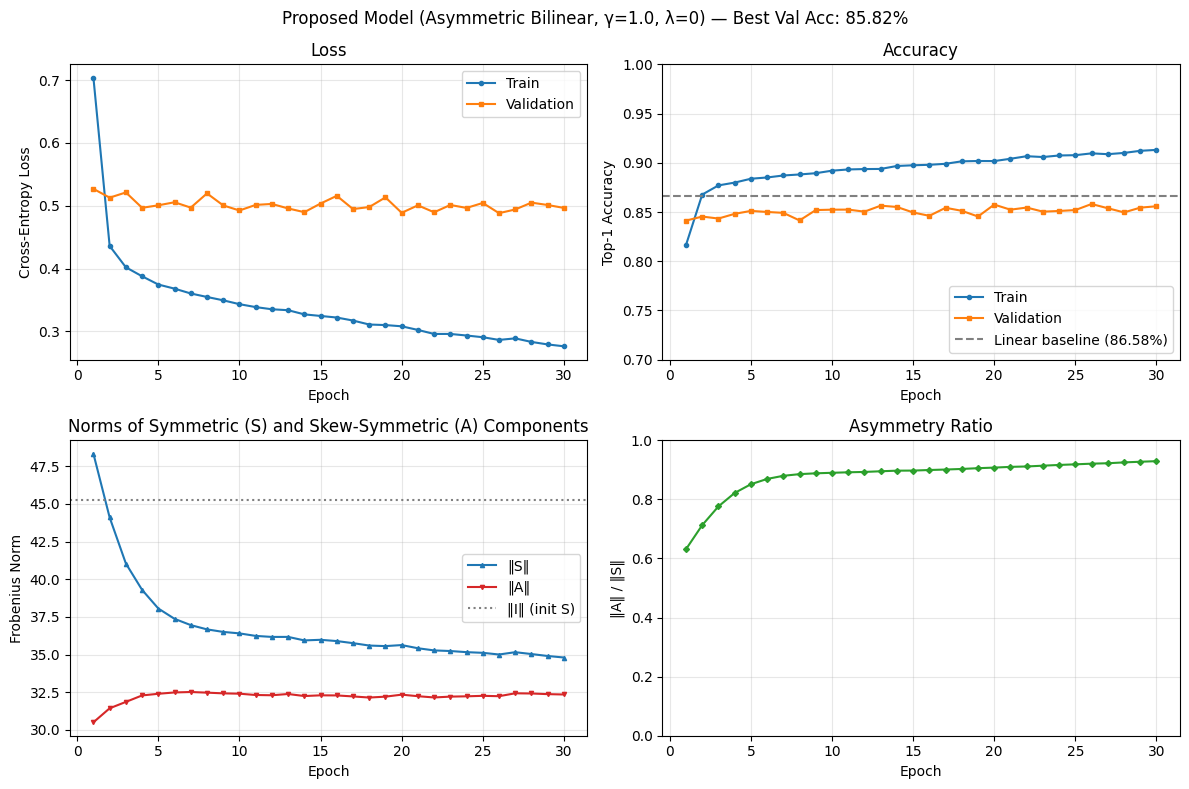

Saved plot to /Users/ayushkumarsingh/ABNS-Project/tversky-asymmetric/results/proposed_asymmetric_g1.0_l0_curves.png


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

epochs = range(1, len(history["train_loss"]) + 1)

# Top-left: loss
axes[0, 0].plot(epochs, history["train_loss"], label="Train", marker="o", markersize=3)
axes[0, 0].plot(epochs, history["val_loss"], label="Validation", marker="s", markersize=3)
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Cross-Entropy Loss")
axes[0, 0].set_title("Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Top-right: accuracy
axes[0, 1].plot(epochs, history["train_acc"], label="Train", marker="o", markersize=3)
axes[0, 1].plot(epochs, history["val_acc"], label="Validation", marker="s", markersize=3)
axes[0, 1].axhline(0.8658, color="gray", linestyle="--", label="Linear baseline (86.58%)")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Top-1 Accuracy")
axes[0, 1].set_title("Accuracy")
axes[0, 1].set_ylim(0.7, 1.0)
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(True, alpha=0.3)

# Bottom-left: norms of S and A
axes[1, 0].plot(epochs, history["S_frob_norm"], label="‖S‖", marker="^", markersize=3, color="C0")
axes[1, 0].plot(epochs, history["A_frob_norm"], label="‖A‖", marker="v", markersize=3, color="C3")
axes[1, 0].axhline(45.25, color="gray", linestyle=":", label="‖I‖ (init S)")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Frobenius Norm")
axes[1, 0].set_title("Norms of Symmetric (S) and Skew-Symmetric (A) Components")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Bottom-right: asymmetry ratio
axes[1, 1].plot(epochs, history["asymmetry_ratio"], marker="D", markersize=3, color="C2")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("‖A‖ / ‖S‖")
axes[1, 1].set_title("Asymmetry Ratio")
axes[1, 1].set_ylim(0, 1.0)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f"Proposed Model (Asymmetric Bilinear, γ=1.0, λ=0) — "
             f"Best Val Acc: {max(history['val_acc']):.2%}", fontsize=12)
plt.tight_layout()

plot_path = RESULTS_DIR / "proposed_asymmetric_g1.0_l0_curves.png"
plt.savefig(plot_path, dpi=120, bbox_inches="tight")
plt.show()

print(f"Saved plot to {plot_path}")